# DialectGuard — Final Run

Fixes three problems found in the previous run and produces every number the paper needs.

**What went wrong**
1. **Attack 1 (paraphrase) never ran.** The original code used `except: return text`, so every failed API call silently returned the original text. Diagnostic confirmed: 100% identical to clean, 0% of AI rows changed. All previously reported RDS values were computed with one dead attack.
2. **Checkpoints were never saved.** Five of six model folders contain only tokenizer files — no weights. Experiment A trained 9 models and saved none.
3. **No content validation.** The old cell checked that attack files existed and had 1500 rows, but never that their contents differed from clean. That is why the dead attack went unnoticed through a full training run.

**What this notebook does**
- **Step 1** regenerates Attack 1 with a working model ID, loud error reporting, and a hard failure if the attack does not actually change the text
- **Step 2** validates all four attack sets by content before any training starts
- **Step 3** retrains 3 models × 3 seeds and **saves each checkpoint with verification**
- **Step 4** aggregates to mean ± std and writes the paper tables

**Expected effect on RDS:** a no-op attack scores at clean accuracy, the maximum. It dragged the attack average up and RDS down. With Attack 1 live, RDS will **rise** from the 6.90 you saw. The direction favours your argument.

Runtime ≈ 3–4 h (Step 3 dominates). Set runtime to **T4 GPU**.


---
## Setup


In [1]:
!pip install -q transformers datasets groq accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 2.7 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, torch

SAVE_ROOT   = '/content/drive/MyDrive/'
SAVE_ATTACK = '/content/drive/MyDrive/SANAD dataset/'
OUT_DIR     = '/content/drive/MyDrive/SANAD dataset/reviewer_experiments/'
CKPT_DIR    = '/content/drive/MyDrive/SANAD dataset/final_checkpoints/'
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

models_info = {
    'AraBERT':    'aubmindlab/bert-base-arabertv2',
    'MARBERT':    'UBC-NLP/MARBERT',
    'AraELECTRA': 'aubmindlab/araelectra-base-discriminator'
}

EVAL_SETS = {
    'Clean':      SAVE_ROOT   + 'test_clean.csv',
    'Paraphrase': SAVE_ATTACK + 'test_attack1_paraphrase.csv',
    'BackTrans':  SAVE_ATTACK + 'test_attack2_backtrans.csv',
    'Dialect':    SAVE_ATTACK + 'test_attack3_dialect.csv',
    'WordDrop':   SAVE_ATTACK + 'test_attack4_worddrop.csv',
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('WARNING: no GPU. Runtime > Change runtime type > T4 GPU')
print('Checkpoints ->', CKPT_DIR)

Device: cuda
GPU: Tesla T4
Checkpoints -> /content/drive/MyDrive/SANAD dataset/final_checkpoints/


In [4]:
import pandas as pd, numpy as np, random
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score

class ArabicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts, self.labels, self.tokenizer, self.max_len = texts, labels, tokenizer, max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(str(self.texts[idx]), max_length=self.max_len,
                             padding='max_length', truncation=True, return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(),
                'attention_mask': enc['attention_mask'].squeeze(),
                'label': torch.tensor(self.labels[idx], dtype=torch.long)}

def evaluate(model, tokenizer, df, batch_size=16):
    loader = DataLoader(ArabicDataset(df['text'].tolist(), df['label'].tolist(), tokenizer),
                        batch_size=batch_size)
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in loader:
            out = model(input_ids=batch['input_ids'].to(device),
                        attention_mask=batch['attention_mask'].to(device))
            preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
            trues.extend(batch['label'].numpy())
    return accuracy_score(trues, preds), f1_score(trues, preds, average='macro')

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

print('Helpers ready.')

Helpers ready.


---
# Step 1 — Regenerate Attack 1 (paraphrase)

The original code swallowed every API error with a bare `except: return text`, so a dead model ID produced a perfect copy of the clean set and reported success.

This version:
- probes which Groq models your key can actually reach and picks a working one
- **reports the first errors instead of hiding them**
- tracks how many calls succeeded
- **raises an exception if the attack did not change the text**, so it cannot silently no-op again

Only the AI rows (`label == 1`) are perturbed; human rows pass through unchanged, matching the original design.


In [5]:
# ---- 1a: Groq client + pick a model that actually works ----
from google.colab import userdata
from groq import Groq

try:
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
except Exception as e:
    raise RuntimeError('Add GROQ_API_KEY to Colab Secrets (key icon, left sidebar).') from e

client = Groq(api_key=GROQ_API_KEY)

# The original notebook used llama-3.1-8b-instant, which appears to have been
# retired. Probe candidates in order and keep the first that responds.
CANDIDATES = [
    'llama-3.1-8b-instant',
    'llama-3.3-70b-versatile',
    'llama-3.2-3b-preview',
    'gemma2-9b-it',
]

try:
    available = sorted(m.id for m in client.models.list().data)
    print('Models visible to this key:')
    for m in available:
        print('   ', m)
except Exception as e:
    available = None
    print('Could not list models:', e)

GEN_MODEL = None
for cand in CANDIDATES:
    if available is not None and cand not in available:
        print(f'  skip {cand} (not in list)')
        continue
    try:
        r = client.chat.completions.create(
            model=cand,
            messages=[{'role': 'user', 'content': 'قل مرحبا'}],
            max_tokens=10)
        _ = r.choices[0].message.content
        GEN_MODEL = cand
        print(f'\nUSING: {GEN_MODEL}')
        break
    except Exception as e:
        print(f'  {cand} failed: {str(e)[:120]}')

if GEN_MODEL is None:
    raise RuntimeError('No working Groq model found. Pick one from the list above and set GEN_MODEL manually.')


Models visible to this key:
    allam-2-7b
    canopylabs/orpheus-arabic-saudi
    canopylabs/orpheus-v1-english
    groq/compound
    groq/compound-mini
    llama-3.1-8b-instant
    llama-3.3-70b-versatile
    meta-llama/llama-prompt-guard-2-22m
    meta-llama/llama-prompt-guard-2-86m
    openai/gpt-oss-120b
    openai/gpt-oss-20b
    openai/gpt-oss-safeguard-20b
    qwen/qwen3.6-27b
    whisper-large-v3
    whisper-large-v3-turbo

USING: llama-3.1-8b-instant


In [ ]:
# ---- 1b: regenerate Attack 1, loudly ----
import time

PARAPHRASE_PROMPT = 'أعد صياغة النص التالي بكلمات مختلفة تماماً مع الحفاظ على المعنى'
para_path = EVAL_SETS['Paraphrase']

clean = pd.read_csv(EVAL_SETS['Clean'])
print(f'clean test set: {len(clean)} rows, {int((clean["label"]==1).sum())} AI rows to attack')

# back up the broken file rather than overwrite it outright
if os.path.exists(para_path):
    bak = para_path.replace('.csv', '_BROKEN_backup.csv')
    if not os.path.exists(bak):
        pd.read_csv(para_path).to_csv(bak, index=False)
        print('backed up old (broken) file ->', bak)

n_ok, n_fail = 0, 0
first_errors = []
texts = []

for i, row in clean.iterrows():
    if row['label'] != 1:
        texts.append(row['text'])            # human rows unchanged
        continue
    src = str(row['text'])[:200]
    try:
        resp = client.chat.completions.create(
            model=GEN_MODEL,
            messages=[{'role': 'user', 'content': f'{PARAPHRASE_PROMPT}:\n{src}'}],
            max_tokens=300)
        out = resp.choices[0].message.content.strip()
        if not out:
            raise ValueError('empty response')
        texts.append(out)
        n_ok += 1
    except Exception as e:
        texts.append(row['text'])            # fallback, but COUNTED
        n_fail += 1
        if len(first_errors) < 5:
            first_errors.append(str(e)[:160])
            print(f'  ERROR row {i}: {str(e)[:160]}')
    if (n_ok + n_fail) % 100 == 0 and (n_ok + n_fail) > 0:
        print(f'  progress: {n_ok+n_fail} attacked | ok={n_ok} fail={n_fail}')
    time.sleep(0.3)

print(f'\nDONE: {n_ok} succeeded, {n_fail} failed')

att = clean.copy()
att['text'] = texts

# HARD CHECK — this is what was missing before
ai = clean['label'] == 1
changed = (att.loc[ai, 'text'].astype(str).values != clean.loc[ai, 'text'].astype(str).values).mean()
print(f'AI rows actually changed: {changed*100:.1f}%')

if changed < 0.50:
    raise RuntimeError(
        f'Attack 1 still not working — only {changed*100:.1f}% of AI rows changed. '
        f'Errors seen: {first_errors}. File NOT saved. Fix the API before continuing.')

att.to_csv(para_path, index=False)
print('saved ->', para_path)


clean test set: 1500 rows, 750 AI rows to attack
backed up old (broken) file -> /content/drive/MyDrive/SANAD dataset/test_attack1_paraphrase_BROKEN_backup.csv
  progress: 100 attacked | ok=100 fail=0
  progress: 200 attacked | ok=200 fail=0
  progress: 300 attacked | ok=300 fail=0
  progress: 400 attacked | ok=400 fail=0
  progress: 500 attacked | ok=500 fail=0
  progress: 600 attacked | ok=600 fail=0
  progress: 700 attacked | ok=700 fail=0

DONE: 750 succeeded, 0 failed
AI rows actually changed: 100.0%
saved -> /content/drive/MyDrive/SANAD dataset/test_attack1_paraphrase.csv


---
# Step 2 — Validate all four attack sets by content

The guard that was missing. Checks that each attack file actually differs from clean **before** committing 3–4 hours to training.

Expected: WordDrop and BackTrans near 100%, Dialect around 70% (lexical substitution only fires when a dictionary word is present), Paraphrase high after Step 1.

Anything at 0% stops the run.


In [6]:
# ---- 2: content validation of every attack set ----
clean = pd.read_csv(EVAL_SETS['Clean'])
ai = clean['label'] == 1

MIN_CHANGE = {'Paraphrase': 0.50, 'BackTrans': 0.50, 'Dialect': 0.30, 'WordDrop': 0.50}

print(f"{'set':<12} {'rows':>6} {'AI rows changed':>17}   status")
problems = []
for name, path in EVAL_SETS.items():
    if name == 'Clean':
        continue
    if not os.path.exists(path):
        print(f'{name:<12} {"--":>6} {"MISSING":>17}   FAIL')
        problems.append(name)
        continue
    d = pd.read_csv(path)
    if len(d) != len(clean):
        print(f'{name:<12} {len(d):>6} {"ROW MISMATCH":>17}   FAIL')
        problems.append(name)
        continue
    changed = (d.loc[ai, 'text'].astype(str).values != clean.loc[ai, 'text'].astype(str).values).mean()
    ok = changed >= MIN_CHANGE[name]
    print(f'{name:<12} {len(d):>6} {changed*100:16.1f}%   {"ok" if ok else "FAIL"}')
    if not ok:
        problems.append(name)

if problems:
    raise RuntimeError(f'Attack sets not usable: {problems}. Fix these before training.')
print('\nAll attack sets validated. Safe to train.')


set            rows   AI rows changed   status
Paraphrase     1500            100.0%   ok
BackTrans      1500            100.0%   ok
Dialect        1500             70.0%   ok
WordDrop       1500            100.0%   ok

All attack sets validated. Safe to train.


---
# Step 3 — Retrain 3 models × 3 seeds, saving checkpoints

Same training procedure as before, with one addition: **every seed-42 model is saved to disk and the save is verified**. If the weights fail to write, the run stops immediately rather than leaving a tokenizer-only folder.

Results are written to a fresh file (`multiseed_v2_raw.json`) so the old contaminated numbers are not reused. Progress is checkpointed after each run, so a disconnect resumes instead of restarting.


In [7]:
from sklearn.model_selection import train_test_split

SEEDS = [42, 1337, 2024]
EPOCHS = 3
BATCH_SIZE = 16

df = pd.read_csv(SAVE_ATTACK + 'AraDeed_final.csv')
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])
val_df, test_df   = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label'])
print(f'AraDeed {len(df)} | Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}')

def train_model_seeded(model_name, train_df, val_df, seed, epochs=EPOCHS, batch_size=BATCH_SIZE):
    set_all_seeds(seed)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

    g = torch.Generator()
    g.manual_seed(seed)
    train_loader = DataLoader(
        ArabicDataset(train_df['text'].tolist(), train_df['label'].tolist(), tokenizer),
        batch_size=batch_size, shuffle=True, generator=g)

    optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=1e-5)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=len(train_loader)//10,
        num_training_steps=len(train_loader)*epochs)

    best_acc, best_state = 0, None
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            out = model(input_ids=batch['input_ids'].to(device),
                        attention_mask=batch['attention_mask'].to(device),
                        labels=batch['label'].to(device))
            out.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += out.loss.item()
        acc, f1 = evaluate(model, tokenizer, val_df)
        print(f'    epoch {epoch+1}: loss {total_loss/len(train_loader):.4f} | val acc {acc:.4f}')
        if acc > best_acc:
            best_acc = acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, tokenizer, best_acc

def save_checkpoint_verified(model, tokenizer, name):
    """Save and confirm the weights actually landed on disk."""
    d = CKPT_DIR + name
    os.makedirs(d, exist_ok=True)
    model.save_pretrained(d, safe_serialization=True)
    tokenizer.save_pretrained(d)
    files = os.listdir(d)
    has_w = any(f in files for f in ('model.safetensors', 'pytorch_model.bin'))
    size = sum(os.path.getsize(os.path.join(d, f)) for f in files
               if os.path.isfile(os.path.join(d, f))) / 1e6
    if not has_w or size < 50:
        raise RuntimeError(f'CHECKPOINT SAVE FAILED for {name}: files={files}, size={size:.1f}MB')
    print(f'  checkpoint saved: {name} ({size:.0f} MB)')

print('Ready.')

AraDeed 10000 | Train 7000 | Val 1500 | Test 1500
Ready.


In [8]:
# ---- 3b: RUN (long) ----
import json, time

records_path = OUT_DIR + 'multiseed_v2_raw.json'   # fresh file, old numbers not reused
records = json.load(open(records_path)) if os.path.exists(records_path) else []
done = {(r['model'], r['seed']) for r in records}
print(f'already complete: {len(done)} runs')

eval_dfs = {k: pd.read_csv(p) for k, p in EVAL_SETS.items()}

for seed in SEEDS:
    for mname, mid in models_info.items():
        if (mname, seed) in done:
            print(f'skip {mname} seed={seed}')
            continue
        print(f'\n=== {mname} | seed {seed} ===')
        t0 = time.time()
        model, tok, val_acc = train_model_seeded(mid, train_df, val_df, seed)

        rec = {'model': mname, 'seed': seed, 'val_acc': round(val_acc*100, 2)}
        for setname, edf in eval_dfs.items():
            acc, f1 = evaluate(model, tok, edf)
            rec[setname] = round(acc*100, 2)
            rec[setname + '_f1'] = round(f1*100, 2)

        attacks = [rec['Paraphrase'], rec['BackTrans'], rec['Dialect'], rec['WordDrop']]
        rec['RDS'] = round(rec['Clean'] - sum(attacks)/len(attacks), 2)
        rec['minutes'] = round((time.time()-t0)/60, 1)

        # save the first-seed model as the canonical detector
        if seed == SEEDS[0]:
            save_checkpoint_verified(model, tok, f'model_{mid.replace("/", "_")}')

        records.append(rec)
        json.dump(records, open(records_path, 'w'), indent=2)
        print(f'  clean {rec["Clean"]} | para {rec["Paraphrase"]} | wd {rec["WordDrop"]} '
              f'| RDS {rec["RDS"]}  ({rec["minutes"]}m)')

        del model
        torch.cuda.empty_cache()

print(f'\nDone. {len(records)} runs -> {records_path}')


already complete: 6 runs
skip AraBERT seed=42
skip MARBERT seed=42
skip AraELECTRA seed=42
skip AraBERT seed=1337
skip MARBERT seed=1337
skip AraELECTRA seed=1337

=== AraBERT | seed 2024 ===


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/720k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  541MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: aubmindlab/araelectra-base-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your do

    epoch 1: loss 0.1434 | val acc 0.9893
    epoch 2: loss 0.0133 | val acc 0.9940
    epoch 3: loss 0.0032 | val acc 0.9953
  clean 99.0 | para 99.33 | wd 74.73 | RDS 6.2  (19.0m)

Done. 9 runs -> /content/drive/MyDrive/SANAD dataset/reviewer_experiments/multiseed_v2_raw.json


---
# Step 4 — Paper tables

Aggregates to mean ± std and prints the numbers to paste into the manuscript, plus a comparison against the old contaminated values so the size of the change is visible.


In [9]:
# ---- 4a: mean ± std ----
import json
raw = pd.DataFrame(json.load(open(OUT_DIR + 'multiseed_v2_raw.json')))
metrics = ['Clean', 'Paraphrase', 'BackTrans', 'Dialect', 'WordDrop', 'RDS']

rows = []
for mname in models_info:
    sub = raw[raw['model'] == mname]
    if len(sub) == 0:
        continue
    row = {'Model': mname, 'n_seeds': len(sub)}
    for m in metrics:
        row[m] = (f"{sub[m].mean():.2f} ± {sub[m].std(ddof=1):.2f}"
                  if len(sub) > 1 else f"{sub[m].mean():.2f}")
    rows.append(row)

summary = pd.DataFrame(rows)
summary.to_csv(OUT_DIR + 'multiseed_v2_summary.csv', index=False)

print('='*100)
print('TABLE: corrected multi-seed results (all four attacks live)')
print('='*100)
print(summary.to_string(index=False))
print('\nPer-run detail:')
print(raw[['model', 'seed'] + metrics].to_string(index=False))


TABLE: corrected multi-seed results (all four attacks live)
     Model  n_seeds        Clean   Paraphrase    BackTrans      Dialect     WordDrop         RDS
   AraBERT        3 97.29 ± 0.03 98.40 ± 0.46 97.36 ± 0.14 96.84 ± 0.08 94.07 ± 1.39 0.62 ± 0.37
   MARBERT        3 95.47 ± 0.20 96.11 ± 0.43 95.80 ± 0.35 95.26 ± 0.12 92.31 ± 0.89 0.60 ± 0.26
AraELECTRA        3 98.96 ± 0.08 99.22 ± 0.10 97.89 ± 0.10 99.16 ± 0.15 72.11 ± 2.57 6.86 ± 0.61

Per-run detail:
     model  seed  Clean  Paraphrase  BackTrans  Dialect  WordDrop  RDS
   AraBERT    42  97.27       98.13      97.20    96.80     94.73 0.55
   MARBERT    42  95.27       95.80      95.53    95.13     91.87 0.69
AraELECTRA    42  98.87       99.20      98.00    99.07     69.60 7.40
   AraBERT  1337  97.33       98.93      97.40    96.80     95.00 0.30
   MARBERT  1337  95.67       96.60      96.20    95.33     93.33 0.31
AraELECTRA  1337  99.00       99.13      97.87    99.07     72.00 6.98
   AraBERT  2024  97.27       98.13   

In [10]:
# ---- 4b: what changed versus the paper's current numbers ----
paper = {  # values currently in the manuscript (single run, dead Attack 1)
    'AraBERT':    {'Clean': 96.67, 'WordDrop': 93.73, 'RDS': 0.24},
    'MARBERT':    {'Clean': 96.40, 'WordDrop': 92.53, 'RDS': -0.04},
    'AraELECTRA': {'Clean': 98.93, 'WordDrop': 64.07, 'RDS': 34.86},
}

print(f"{'Model':<12} {'metric':<10} {'paper':>8} {'corrected':>18} {'delta':>9}")
print('-'*62)
for mname in models_info:
    sub = raw[raw['model'] == mname]
    if len(sub) == 0:
        continue
    for m in ['Clean', 'WordDrop', 'RDS']:
        new = sub[m].mean()
        sd  = sub[m].std(ddof=1)
        old = paper[mname][m]
        print(f'{mname:<12} {m:<10} {old:8.2f} {f"{new:.2f} ± {sd:.2f}":>18} {new-old:+9.2f}')
    print()

print('Paraphrase column sanity check (must NOT equal Clean):')
for mname in models_info:
    sub = raw[raw['model'] == mname]
    if len(sub) == 0:
        continue
    c, p = sub['Clean'].mean(), sub['Paraphrase'].mean()
    print(f'  {mname:<12} clean {c:6.2f} | paraphrase {p:6.2f} | diff {c-p:+6.2f}'
          f'{"   <-- STILL BROKEN" if abs(c-p) < 0.01 else ""}')


Model        metric        paper          corrected     delta
--------------------------------------------------------------
AraBERT      Clean         96.67       97.29 ± 0.03     +0.62
AraBERT      WordDrop      93.73       94.07 ± 1.39     +0.34
AraBERT      RDS            0.24        0.62 ± 0.37     +0.38

MARBERT      Clean         96.40       95.47 ± 0.20     -0.93
MARBERT      WordDrop      92.53       92.31 ± 0.89     -0.22
MARBERT      RDS           -0.04        0.60 ± 0.26     +0.64

AraELECTRA   Clean         98.93       98.96 ± 0.08     +0.03
AraELECTRA   WordDrop      64.07       72.11 ± 2.57     +8.04
AraELECTRA   RDS           34.86        6.86 ± 0.61    -28.00

Paraphrase column sanity check (must NOT equal Clean):
  AraBERT      clean  97.29 | paraphrase  98.40 | diff  -1.11
  MARBERT      clean  95.47 | paraphrase  96.11 | diff  -0.64
  AraELECTRA   clean  98.96 | paraphrase  99.22 | diff  -0.26


In [12]:
# ---- 4c: confirm checkpoints exist, then collect outputs ----
print('Checkpoints in', CKPT_DIR)
for d in sorted(os.listdir(CKPT_DIR)):
    p = os.path.join(CKPT_DIR, d)
    if not os.path.isdir(p):
        continue
    files = os.listdir(p)
    has_w = any(f in files for f in ('model.safetensors', 'pytorch_model.bin'))
    size = sum(os.path.getsize(os.path.join(p, f)) for f in files
               if os.path.isfile(os.path.join(p, f))) / 1e6
    print(f'  {"WEIGHTS" if has_w else "NO WTS "} | {size:7.1f} MB | {d}')

print('\nOutputs in', OUT_DIR)
for f in sorted(os.listdir(OUT_DIR)):
    print('  ', f)

Checkpoints in /content/drive/MyDrive/SANAD dataset/final_checkpoints/
  WEIGHTS |   654.1 MB | model_UBC-NLP_MARBERT
  WEIGHTS |   542.6 MB | model_aubmindlab_araelectra-base-discriminator
  WEIGHTS |   542.5 MB | model_aubmindlab_bert-base-arabertv2

Outputs in /content/drive/MyDrive/SANAD dataset/reviewer_experiments/
   crossmodel_LLaMA-3_3-70B.csv
   fig_attack_accuracy.png
   fig_rds.png
   fig_recovery.png
   multiseed_raw.json
   multiseed_summary.csv
   multiseed_v2_raw.json
   multiseed_v2_summary.csv


In [13]:
import json, pandas as pd
raw = pd.DataFrame(json.load(open('/content/drive/MyDrive/SANAD dataset/reviewer_experiments/multiseed_v2_raw.json')))
for m in ['AraBERT','MARBERT','AraELECTRA']:
    s = raw[raw['model']==m]
    print(f"{m:12s} val {s['val_acc'].mean():.2f} ± {s['val_acc'].std(ddof=1):.2f} | "
          f"cleanF1 {s['Clean_f1'].mean():.2f} ± {s['Clean_f1'].std(ddof=1):.2f}")

AraBERT      val 97.45 ± 0.04 | cleanF1 97.29 ± 0.03
MARBERT      val 96.87 ± 0.07 | cleanF1 95.46 ± 0.20
AraELECTRA   val 99.40 ± 0.23 | cleanF1 98.96 ± 0.08


In [14]:
# ---- load the CORRECTED results and sanity-check them ----
import json, os
import pandas as pd, numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 10
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

OUT_DIR = '/content/drive/MyDrive/SANAD dataset/reviewer_experiments/'
RAW = OUT_DIR + 'multiseed_v2_raw.json'

if not os.path.exists(RAW):
    raise FileNotFoundError(f'{RAW} not found. Run the Final Run notebook first.')

raw = pd.DataFrame(json.load(open(RAW)))
MODELS = ['AraBERT', 'MARBERT', 'AraELECTRA']
CONDS  = ['Clean', 'Paraphrase', 'BackTrans', 'Dialect', 'WordDrop']

print(f'runs loaded: {len(raw)}  seeds: {sorted(raw["seed"].unique())}')

# Guard: this file must be the corrected one, not the contaminated run.
bad = []
for m in MODELS:
    s = raw[raw['model'] == m]
    if abs(s['Clean'].mean() - s['Paraphrase'].mean()) < 0.01:
        bad.append(m)
if bad:
    raise RuntimeError(f'Paraphrase == Clean for {bad}. This is the OLD contaminated data.')
print('data verified: Paraphrase differs from Clean for all models\n')

print(raw[['model', 'seed'] + CONDS + ['RDS']].to_string(index=False))


runs loaded: 9  seeds: [np.int64(42), np.int64(1337), np.int64(2024)]
data verified: Paraphrase differs from Clean for all models

     model  seed  Clean  Paraphrase  BackTrans  Dialect  WordDrop  RDS
   AraBERT    42  97.27       98.13      97.20    96.80     94.73 0.55
   MARBERT    42  95.27       95.80      95.53    95.13     91.87 0.69
AraELECTRA    42  98.87       99.20      98.00    99.07     69.60 7.40
   AraBERT  1337  97.33       98.93      97.40    96.80     95.00 0.30
   MARBERT  1337  95.67       96.60      96.20    95.33     93.33 0.31
AraELECTRA  1337  99.00       99.13      97.87    99.07     72.00 6.98
   AraBERT  2024  97.27       98.13      97.47    96.93     92.47 1.02
   MARBERT  2024  95.47       95.93      95.67    95.33     91.73 0.80
AraELECTRA  2024  99.00       99.33      97.80    99.33     74.73 6.20


In [15]:
# ---- archive the contaminated PNGs instead of overwriting them ----
old_names = ['fig_attack_accuracy.png', 'fig_rds.png', 'fig_recovery.png', 'fig_crossmodel.png']
for f in old_names:
    src = OUT_DIR + f
    if os.path.exists(src):
        dst = OUT_DIR + f.replace('.png', '_OLD_contaminated.png')
        if not os.path.exists(dst):
            os.rename(src, dst)
            print('archived:', f, '->', os.path.basename(dst))
        else:
            print('already archived:', f)
    else:
        print('not present:', f)


archived: fig_attack_accuracy.png -> fig_attack_accuracy_OLD_contaminated.png
archived: fig_rds.png -> fig_rds_OLD_contaminated.png
archived: fig_recovery.png -> fig_recovery_OLD_contaminated.png
not present: fig_crossmodel.png


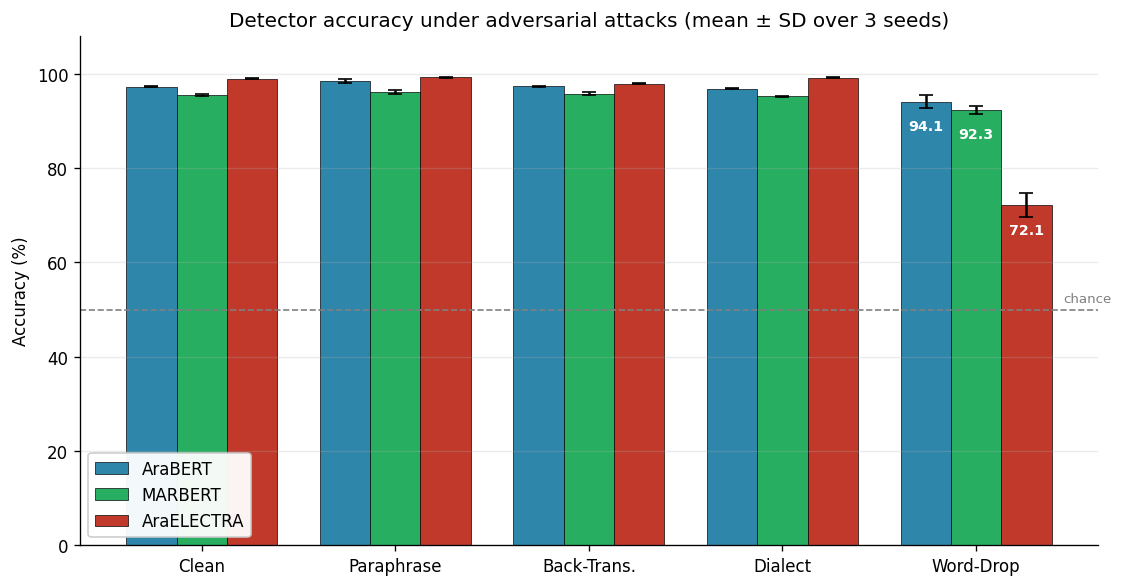

saved fig1_attack_accuracy.png


In [16]:
# ---- Figure 1: accuracy under each condition, seed error bars ----
COLORS = {'AraBERT': '#2E86AB', 'MARBERT': '#27AE60', 'AraELECTRA': '#C0392B'}
LABELS = ['Clean', 'Paraphrase', 'Back-Trans.', 'Dialect', 'Word-Drop']

x = np.arange(len(CONDS))
w = 0.26

fig, ax = plt.subplots(figsize=(9.5, 5))
for i, m in enumerate(MODELS):
    s = raw[raw['model'] == m]
    means = [s[c].mean() for c in CONDS]
    errs  = [s[c].std(ddof=1) for c in CONDS]
    bars = ax.bar(x + (i-1)*w, means, w, yerr=errs, capsize=4,
                  label=m, color=COLORS[m], edgecolor='black', linewidth=0.4)
    # annotate the word-drop bars, which carry the finding
    ax.text(x[-1] + (i-1)*w, means[-1] - 6, f'{means[-1]:.1f}',
            ha='center', fontsize=8.5, fontweight='bold', color='white')

ax.axhline(50, ls='--', lw=1, color='grey')
ax.text(4.45, 51.5, 'chance', fontsize=8, color='grey')
ax.set_xticks(x)
ax.set_xticklabels(LABELS)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 108)
ax.set_title('Detector accuracy under adversarial attacks (mean ± SD over 3 seeds)')
ax.legend(loc='lower left', framealpha=0.95)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig1_attack_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()
print('saved fig1_attack_accuracy.png')


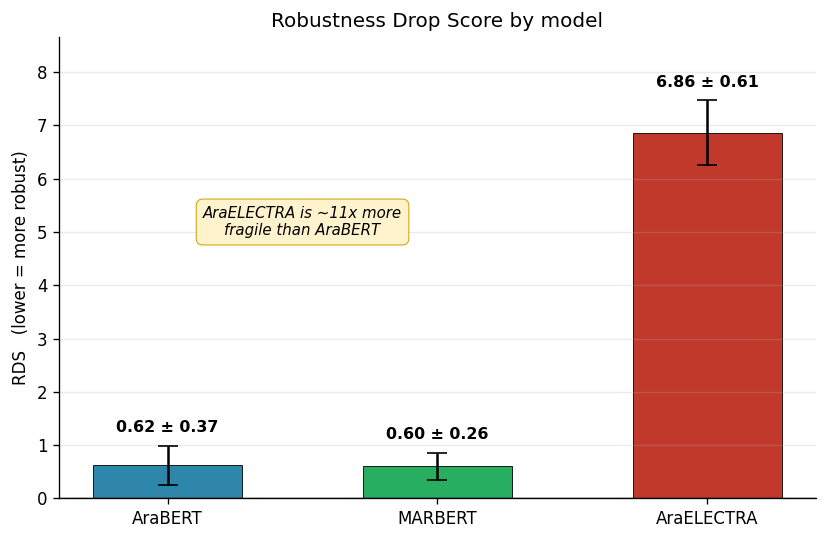

saved fig2_rds.png


In [17]:
# ---- Figure 2: RDS comparison ----
fig, ax = plt.subplots(figsize=(7, 4.6))

names, means, errs = [], [], []
for m in MODELS:
    s = raw[raw['model'] == m]
    names.append(m)
    means.append(s['RDS'].mean())
    errs.append(s['RDS'].std(ddof=1))

bars = ax.bar(names, means, yerr=errs, capsize=6,
              color=[COLORS[m] for m in names], edgecolor='black', linewidth=0.5, width=0.55)
for b, mu, e in zip(bars, means, errs):
    ax.text(b.get_x() + b.get_width()/2, mu + e + 0.25,
            f'{mu:.2f} ± {e:.2f}', ha='center', fontweight='bold', fontsize=9.5)

ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('RDS   (lower = more robust)')
ax.set_ylim(0, max(means) + 1.8)
ax.set_title('Robustness Drop Score by model')
ax.grid(axis='y', alpha=0.25)

ratio = means[MODELS.index('AraELECTRA')] / max(means[MODELS.index('AraBERT')], 1e-9)
ax.text(0.5, max(means)*0.72,
        f'AraELECTRA is ~{ratio:.0f}x more\nfragile than AraBERT',
        fontsize=9, style='italic', ha='center',
        bbox=dict(boxstyle='round,pad=0.45', facecolor='#FFF3CD', edgecolor='#C8A200', lw=0.6))

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig2_rds.png', dpi=300, bbox_inches='tight')
plt.show()
print('saved fig2_rds.png')


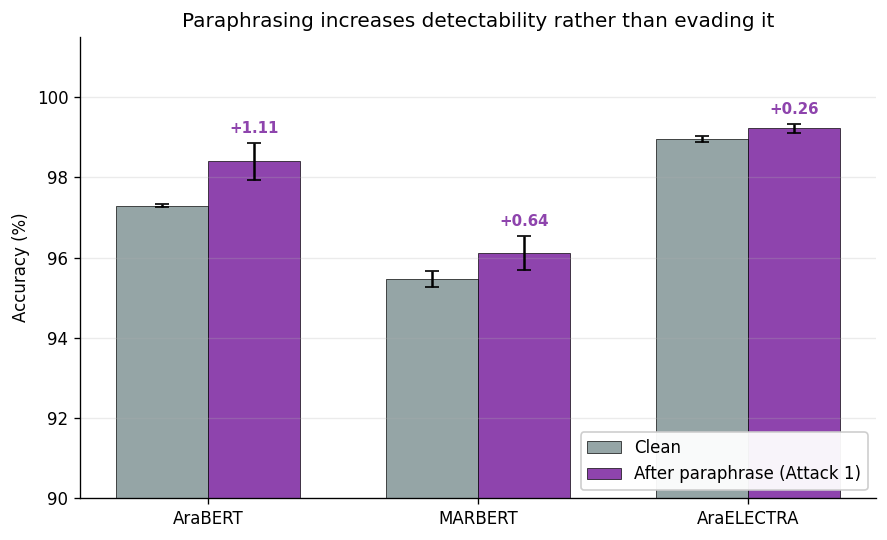

saved fig3_paraphrase.png

deltas (paraphrase - clean):
  AraBERT      +1.11
  MARBERT      +0.64
  AraELECTRA   +0.26


In [18]:
# ---- Figure 3 (NEW): paraphrasing does not evade detection ----
# Supports the Results 4.2 finding: accuracy RISES under Attack 1.
fig, ax = plt.subplots(figsize=(7.5, 4.6))

x = np.arange(len(MODELS))
w = 0.34
clean_m = [raw[raw['model'] == m]['Clean'].mean() for m in MODELS]
clean_e = [raw[raw['model'] == m]['Clean'].std(ddof=1) for m in MODELS]
para_m  = [raw[raw['model'] == m]['Paraphrase'].mean() for m in MODELS]
para_e  = [raw[raw['model'] == m]['Paraphrase'].std(ddof=1) for m in MODELS]

ax.bar(x - w/2, clean_m, w, yerr=clean_e, capsize=4, label='Clean',
       color='#95A5A6', edgecolor='black', linewidth=0.4)
ax.bar(x + w/2, para_m, w, yerr=para_e, capsize=4, label='After paraphrase (Attack 1)',
       color='#8E44AD', edgecolor='black', linewidth=0.4)

for i in range(len(MODELS)):
    delta = para_m[i] - clean_m[i]
    ax.annotate(f'+{delta:.2f}',
                xy=(x[i] + w/2, para_m[i] + para_e[i] + 0.25),
                ha='center', fontsize=9, fontweight='bold', color='#8E44AD')

ax.set_xticks(x)
ax.set_xticklabels(MODELS)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(90, 101.5)
ax.set_title('Paraphrasing increases detectability rather than evading it')
ax.legend(loc='lower right', framealpha=0.95)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig3_paraphrase.png', dpi=300, bbox_inches='tight')
plt.show()
print('saved fig3_paraphrase.png')
print('\ndeltas (paraphrase - clean):')
for i, m in enumerate(MODELS):
    print(f'  {m:12s} {para_m[i]-clean_m[i]:+.2f}')


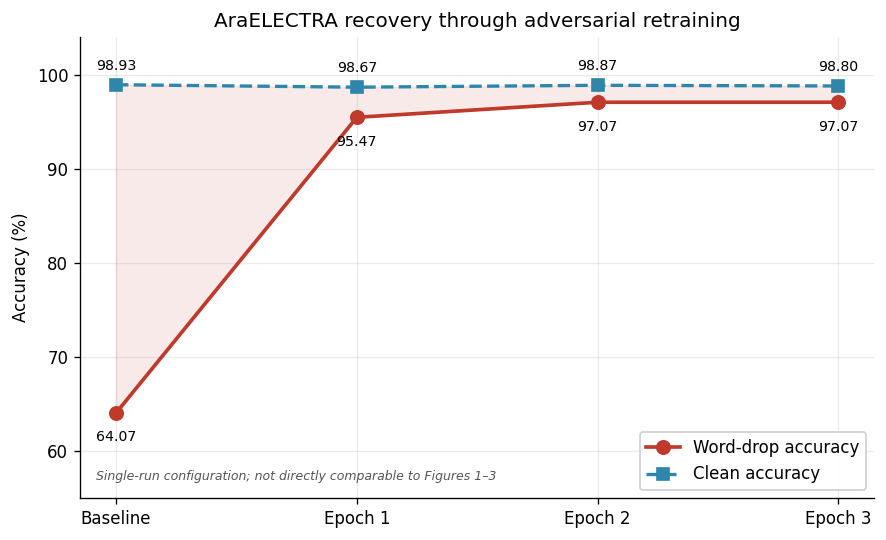

saved fig4_recovery.png


In [19]:
# ---- Figure 4: defense recovery (earlier single-run setup) ----
# These values come from the ORIGINAL defense experiment, not the corrected
# multi-seed run. The caveat is drawn on the figure so it cannot be misread
# as directly comparable to Figures 1-3.
epochs   = ['Baseline', 'Epoch 1', 'Epoch 2', 'Epoch 3']
worddrop = [64.07, 95.47, 97.07, 97.07]
cleanacc = [98.93, 98.67, 98.87, 98.80]

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot(epochs, worddrop, 'o-', lw=2.2, ms=8, color='#C0392B', label='Word-drop accuracy')
ax.plot(epochs, cleanacc, 's--', lw=2, ms=7, color='#2E86AB', label='Clean accuracy')
ax.fill_between(range(len(epochs)), worddrop, cleanacc, alpha=0.10, color='#C0392B')

for i, (wd, ca) in enumerate(zip(worddrop, cleanacc)):
    ax.annotate(f'{wd:.2f}', (i, wd), textcoords='offset points',
                xytext=(0, -17), ha='center', fontsize=8.5)
    ax.annotate(f'{ca:.2f}', (i, ca), textcoords='offset points',
                xytext=(0, 9), ha='center', fontsize=8.5)

ax.set_ylabel('Accuracy (%)')
ax.set_ylim(55, 104)
ax.set_title('AraELECTRA recovery through adversarial retraining')
ax.legend(loc='lower right', framealpha=0.95)
ax.grid(alpha=0.25)
ax.text(0.02, 0.04,
        'Single-run configuration; not directly comparable to Figures 1–3',
        transform=ax.transAxes, fontsize=7.5, style='italic', color='#555555')
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig4_recovery.png', dpi=300, bbox_inches='tight')
plt.show()
print('saved fig4_recovery.png')
